In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import numpy as np

from models import *
from cosmology import CosmologyMCMC

In [2]:
file = 'data/DES-Dovekie_HD.csv'

with open(file) as f:
    for i, line in enumerate(f):
        if line.startswith('VARNAMES:'):
            header_line = line
            header_idx = i
            break

cols = header_line.replace("VARNAMES:", "").split()

df = pd.read_csv(file, sep='\s+', skiprows=header_idx + 1, header=None).iloc[:, 1:]
df.columns = cols

low_z = df[df['IDSURVEY'] != 10]
high_z = df[df['IDSURVEY'] == 10]
high_z

,CID,IDSURVEY,zHD,zHEL,MU,MUERR,MUERR_VPEC,MUERR_SYS,PROBIA_BEAMS
187,1371046,10,0.07334,0.07411,37.60807,0.1792,0.0307,0.39882,1.00000
188,1318737,10,0.07374,0.07451,37.36177,0.1858,0.0305,0.06818,1.00000
199,1864053,10,0.09333,0.09422,38.14556,0.0994,0.0243,0.06934,1.00000
200,1344303,10,0.09394,0.09475,38.19696,0.2395,0.0242,0.13223,0.99969
201,1317612,10,0.10442,0.10525,38.35683,0.1256,0.0218,0.02734,0.99996
...,...,...,...,...,...,...,...,...,...
1815,1263785,10,1.06420,1.06498,44.23028,0.1451,0.0028,0.03884,0.99765
1816,1842087,10,1.08349,1.08430,44.52159,0.1518,0.0027,0.13563,0.99789
1817,1339609,10,1.12132,1.12212,44.20175,0.1075,0.0026,0.06526,0.98858
1818,1446080,10,1.13057,1.13140,44.52710,0.1585,0.0026,0.11217,0.99945


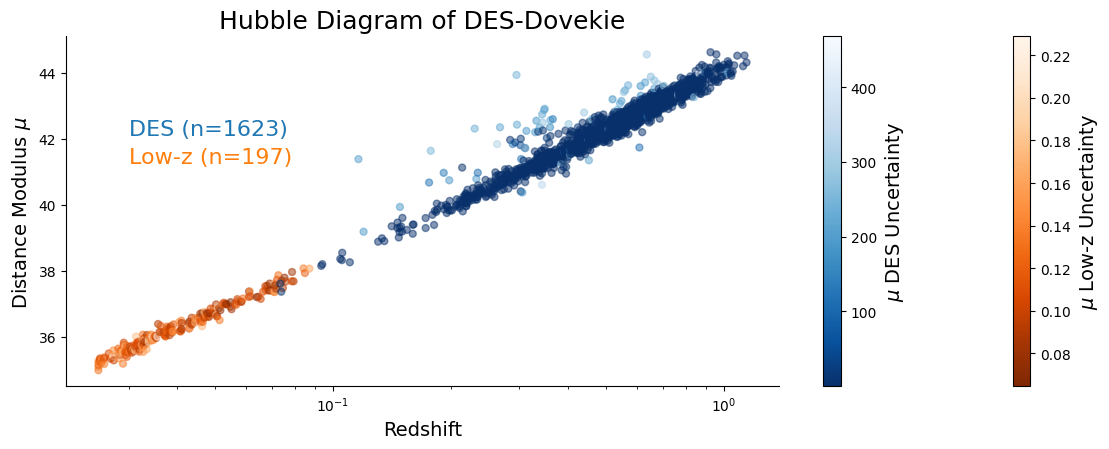

In [3]:
plt.figure(figsize=(12, 4.6))

plt.scatter(low_z['zHD'], low_z['MU'], c=low_z['MUERR'], s=25, cmap='Oranges_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ Low-z Uncertainty', size=14)
plt.scatter(high_z['zHD'], high_z['MU'], c=high_z['MUERR'], s=25, cmap='Blues_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ DES Uncertainty', size=14)


plt.xscale('log')
plt.ylabel('Distance Modulus $\mu$', size=14)
plt.xlabel('Redshift', size=14)
plt.title('Hubble Diagram of DES-Dovekie', size=18)
plt.text(0.03, 42, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
plt.text(0.03, 41.75, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

remove high MU uncertainty points

In [4]:
df = df[df['MUERR'] < 0.4]

low_z = low_z[low_z['MUERR'] < 0.4]
high_z = high_z[high_z['MUERR'] < 0.4]

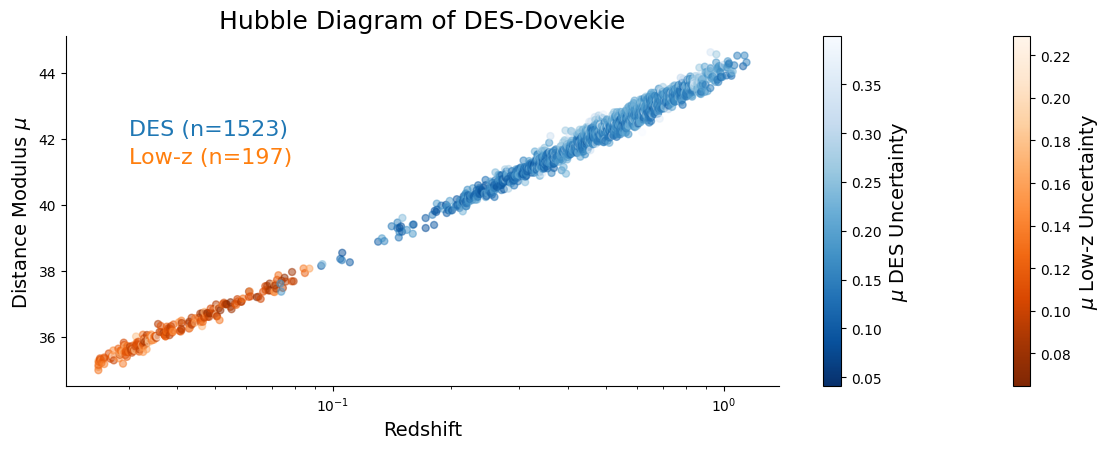

In [5]:
plt.figure(figsize=(12, 4.6))

plt.scatter(low_z['zHD'], low_z['MU'], c=low_z['MUERR'], s=25, cmap='Oranges_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ Low-z Uncertainty', size=14)
plt.scatter(high_z['zHD'], high_z['MU'], c=high_z['MUERR'], s=25, cmap='Blues_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ DES Uncertainty', size=14)


plt.xscale('log')
plt.ylabel('Distance Modulus $\mu$', size=14)
plt.xlabel('Redshift', size=14)
plt.title('Hubble Diagram of DES-Dovekie', size=18)
plt.text(0.03, 42, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
plt.text(0.03, 41.75, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# MCMC

## lCDM Model

In [6]:
lcdm_sampler = CosmologyMCMC(LambdaCDMModel(), df)

n_walkers = 16
n_iterations = 2000
p0 = np.random.multivariate_normal(mean=[73, 0.3, 0.7], cov=np.diag([1, 1e-12, 1e-12]), size=n_walkers)

lcdm_sampler.test_priors(p0)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [7]:
lcdm_sampler.run_mcmc(n_walkers, n_iterations, p0)

100%|██████████| 2000/2000 [01:18<00:00, 25.56it/s]

lCDM model took 78.271 seconds


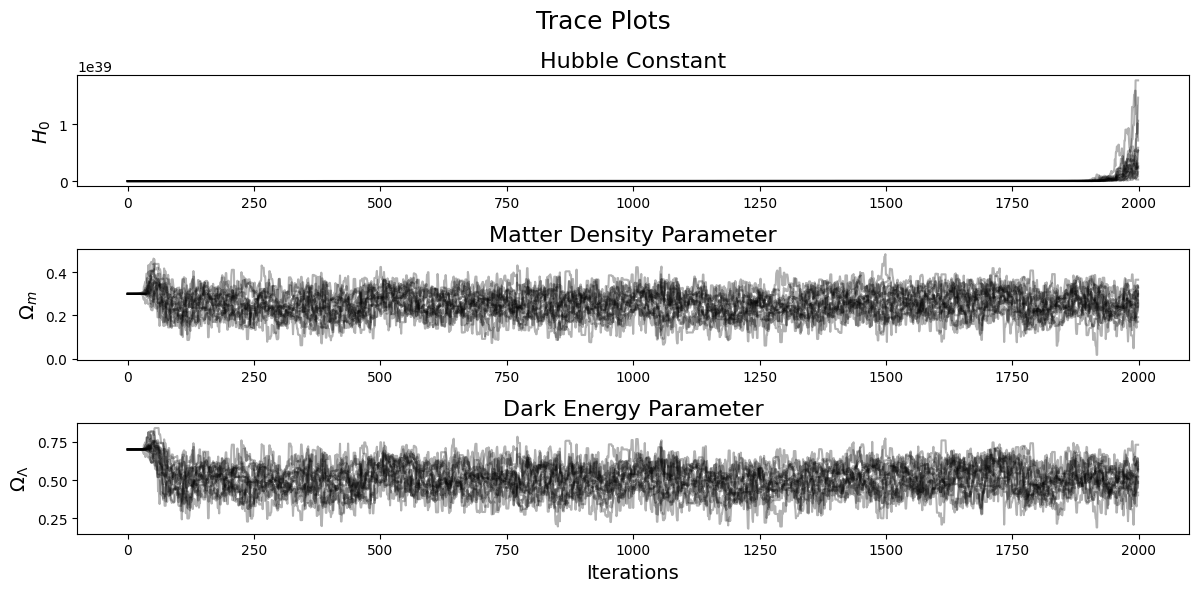

In [8]:
lcdm_sampler.trace_plots()

In [9]:
burned = pd.DataFrame(lcdm_sampler.get_samples(discard=1000, flat=True), columns=['H_0', 'Om_m', 'Om_l'])
burned['Om_k'] = 1.0 - burned['Om_m'] - burned['Om_l']
lcdm_sampler.burned = burned.sort_values(by='Om_m')

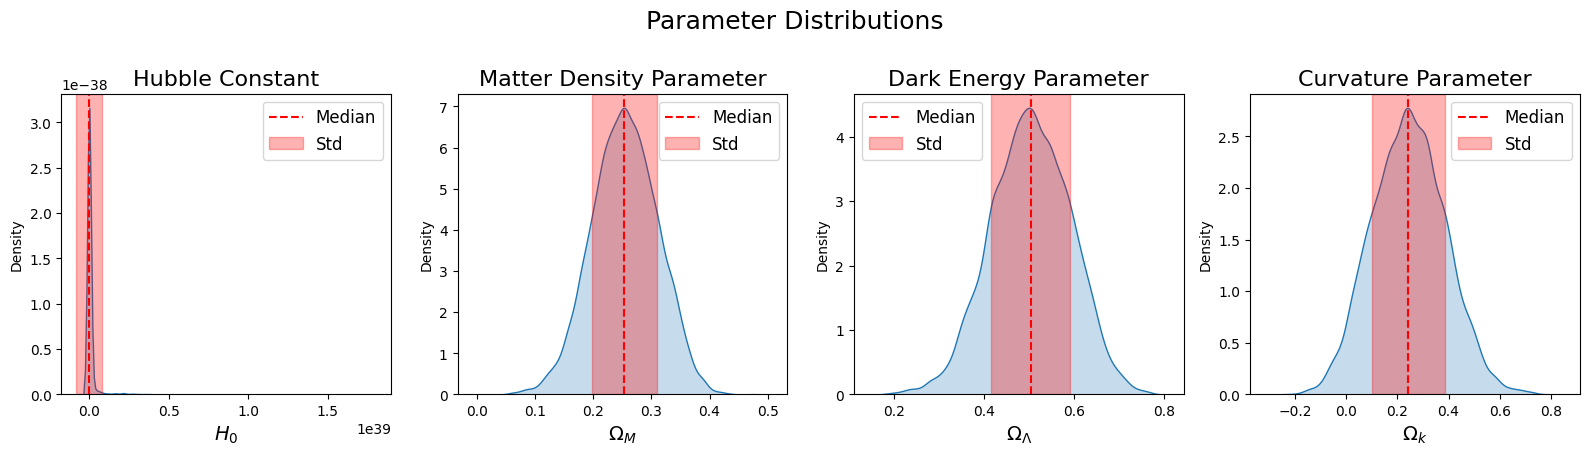

In [10]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4.6))

titles = ['Hubble Constant', 'Matter Density Parameter', 'Dark Energy Parameter', 'Curvature Parameter']
x_labels = [r'$H_0$', r'$\Omega_M$', r'$\Omega_\Lambda$', r'$\Omega_k$']
for i in range(0, 4):
    sns.kdeplot(lcdm_sampler.burned.iloc[:,i], fill=True, ax=axs[i])
    axs[i].set_xlabel(x_labels[i], size=14)
    axs[i].set_title(titles[i], size=16)
    median = np.median(lcdm_sampler.burned.iloc[:,i])
    std = np.std(lcdm_sampler.burned.iloc[:,i])
    axs[i].axvline(median, color='red', linestyle='dashed', label='Median')
    axs[i].axvspan(median-std, median+std, color='red', alpha=0.3, label='Std')
    axs[i].legend(fontsize=12)

fig.suptitle('Parameter Distributions', size=18)
plt.tight_layout()
plt.show()

In [11]:
print(f"Om_m = {lcdm_sampler.burned['Om_m'].median():.2f} ± {lcdm_sampler.burned['Om_m'].std():.2f}")
print(f"Om_l = {lcdm_sampler.burned['Om_l'].median():.2f} ± {lcdm_sampler.burned['Om_l'].std():.2f}")
print(f"Om_k = {lcdm_sampler.burned['Om_k'].median():.2f} ± {lcdm_sampler.burned['Om_k'].std():.2f}")

Om_m = 0.25 ± 0.06
Om_l = 0.50 ± 0.09
Om_k = 0.24 ± 0.14


## FlatwCDM Model

In [12]:
fwcdm_sampler = CosmologyMCMC(FlatwCDMModel(), df)

n_walkers = 16
n_iterations = 2000
p0 = np.random.multivariate_normal(mean=[73, 0.3, 0], cov=np.diag([1, 1e-12, 1e-12]), size=n_walkers)

fwcdm_sampler.test_priors(p0)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [13]:
fwcdm_sampler.run_mcmc(n_walkers, n_iterations, p0)

100%|██████████| 2000/2000 [05:45<00:00,  5.80it/s]

FlatwCDM model took 345.100 seconds


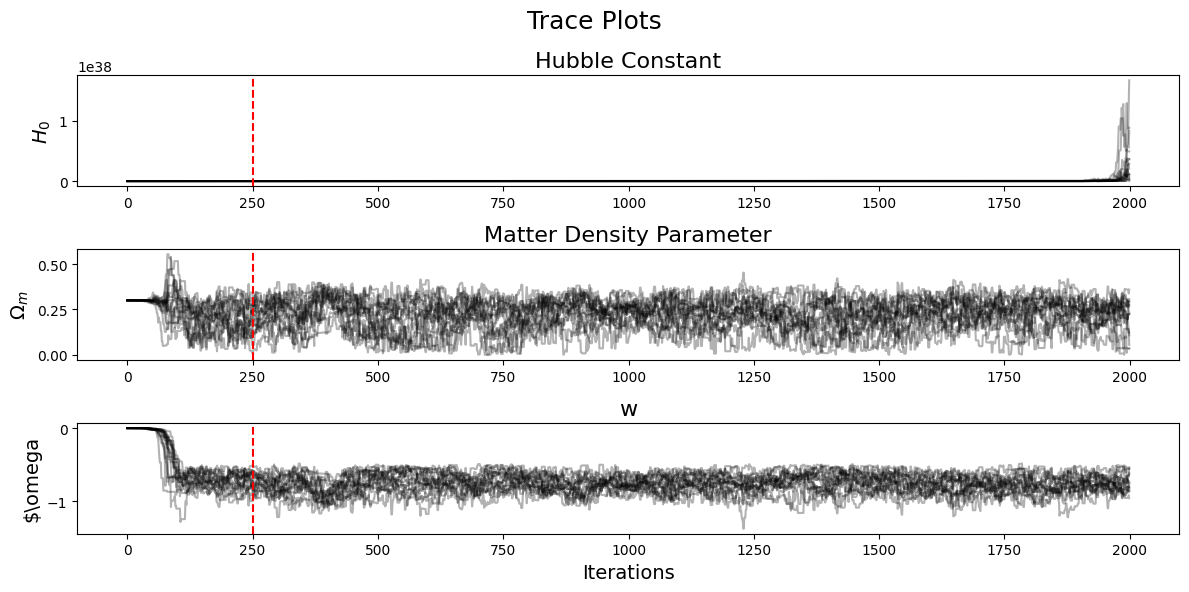

In [14]:
fwcdm_sampler.trace_plots(250)

In [15]:
fwcdm_sampler.burned = pd.DataFrame(fwcdm_sampler.get_samples(discard=250, flat=True), columns=['H_0', 'Om_m', 'w'])

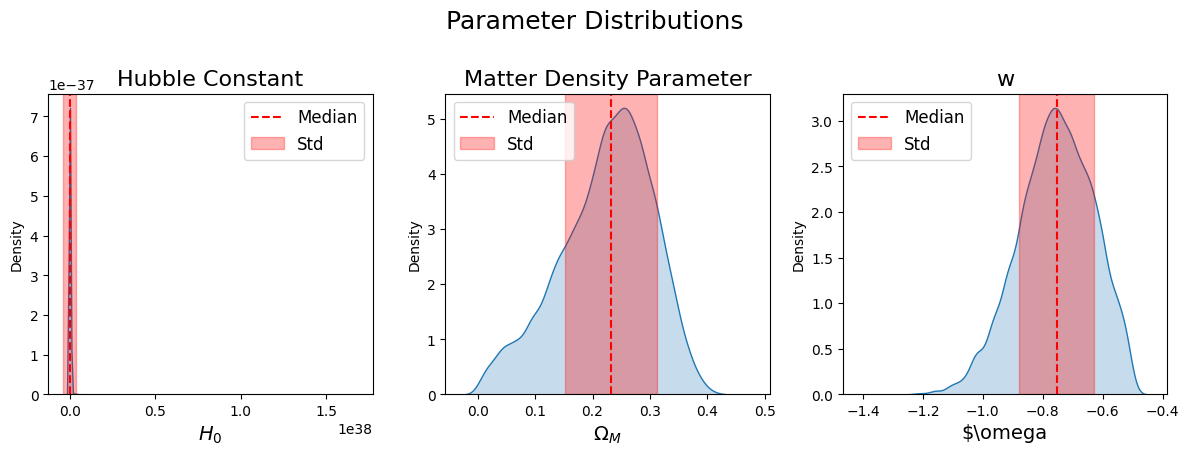

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4.6))

titles = ['Hubble Constant', 'Matter Density Parameter', 'w']
x_labels = [r'$H_0$', r'$\Omega_M$', r'$\omega']
for i in range(0, 3):
    sns.kdeplot(fwcdm_sampler.burned.iloc[:,i], fill=True, ax=axs[i])
    axs[i].set_xlabel(x_labels[i], size=14)
    axs[i].set_title(titles[i], size=16)
    median = np.median(fwcdm_sampler.burned.iloc[:,i])
    std = np.std(fwcdm_sampler.burned.iloc[:,i])
    axs[i].axvline(median, color='red', linestyle='dashed', label='Median')
    axs[i].axvspan(median-std, median+std, color='red', alpha=0.3, label='Std')
    axs[i].legend(fontsize=12)

fig.suptitle('Parameter Distributions', size=18)
plt.tight_layout()
plt.show()

In [17]:
print(f"Om_m = {fwcdm_sampler.burned['Om_m'].median():.2f} ± {fwcdm_sampler.burned['Om_m'].std():.2f}")
print(f"w = {fwcdm_sampler.burned['w'].median():.2f} ± {fwcdm_sampler.burned['w'].std():.2f}")

Om_m = 0.23 ± 0.08
w = -0.75 ± 0.12


# Analysis

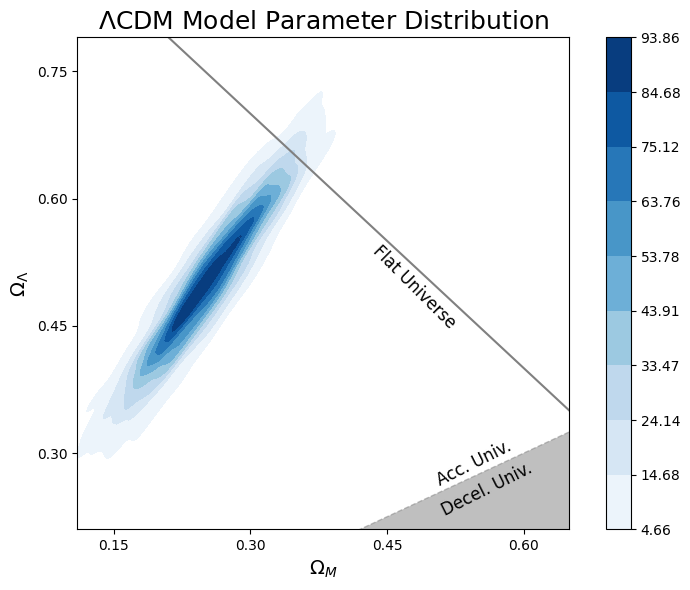

In [76]:
fig, ax = plt.subplots(figsize=(8,6))
ax.set_box_aspect(1) 

sns.kdeplot(x=lcdm_sampler.burned['Om_m'], y=lcdm_sampler.burned['Om_l'], cmap='Blues', fill=True, cbar=True)

X = np.linspace(0, 1, 100)
plt.plot(X, 1 - X, color='gray')
plt.fill_between(X, 0.5*X, color='gray', alpha=0.5, linestyle='dashed')

rotn = np.degrees(np.arctan2(1, 2))
plt.annotate('Acc. Univ.', xy=(0.545, 0.2875), ha='center', va='center', rotation=rotn, fontsize=12)
plt.annotate('Decel. Univ.', xy=(0.56, 0.2575), ha='center', va='center', rotation=rotn, fontsize=12)

rotn = np.degrees(np.arctan2(X[0]-X[1], X[1]-X[0]))
plt.annotate('Flat Universe', xy=(0.48, 0.495), ha='center', va='center', rotation=rotn, fontsize=12)

plt.xlabel('$\Omega_M$', size=14)
plt.ylabel('$\Omega_\Lambda$', size=14)
plt.xlim(0.11, 0.65)
plt.ylim(0.21, 0.79)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.15))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.15))
plt.title('$\Lambda$CDM Model Parameter Distribution', size=18)
plt.tight_layout()
plt.show()

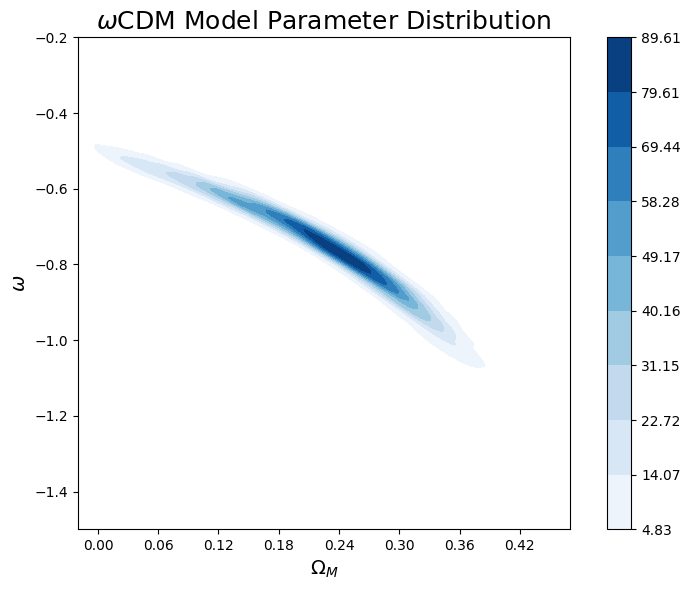

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
ax.set_box_aspect(1) 

sns.kdeplot(fwcdm_sampler.burned, x='Om_m', y='w', cmap='Blues', fill=True, cbar=True)

plt.axhline(-1, color='black', linestyle='dotted')

plt.xlabel('$\Omega_M$', size=14)
plt.ylabel('$\omega$', size=14)
plt.xlim(-0.04, 0.46)
plt.ylim(-1.5, -0.2)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.06))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
plt.title('$\omega$CDM Model Parameter Distribution', size=18)
plt.tight_layout()
plt.show()

In [19]:
z_grid = np.logspace(np.log10(df['zHD'].min()), np.log10(df['zHD'].max()), 200)

idx = np.random.choice(len(lcdm_sampler.burned), size=100, replace=False) # random samples from chain

mu_curves = []
for i in idx:
    mu_curves.append(lcdm_sampler.mu_model_corrected(lcdm_sampler.burned.iloc[i][:3], z_grid))

mu_curves = np.array(mu_curves)
mu_med = np.median(mu_curves, axis=0)
mu_16 = np.percentile(mu_curves, 16, axis=0)
mu_84 = np.percentile(mu_curves, 84, axis=0)

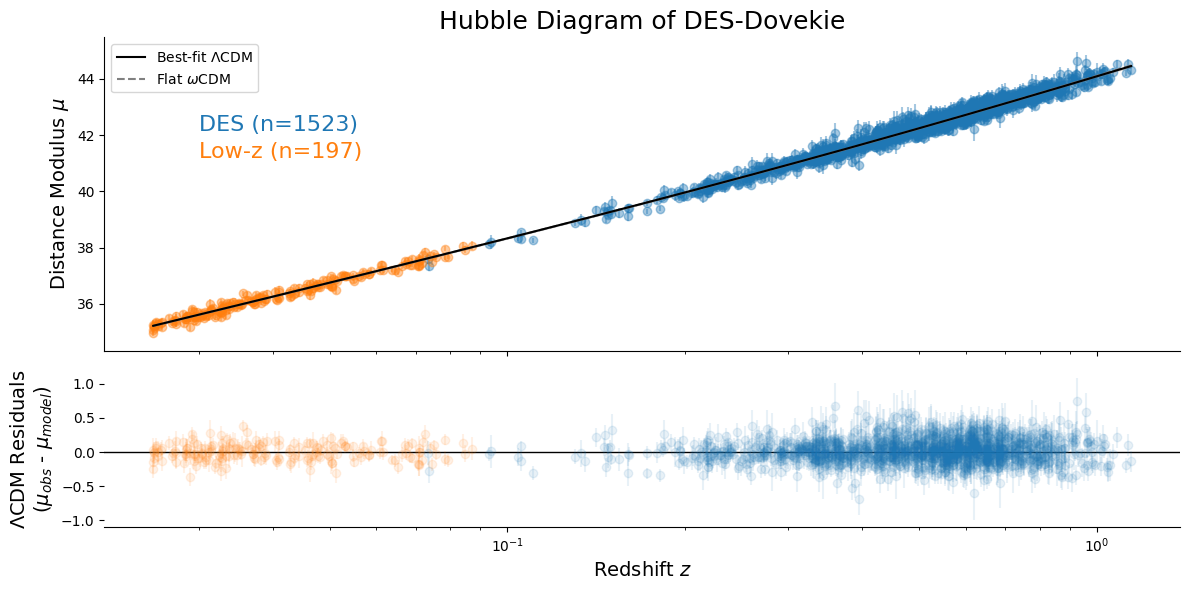

In [107]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# data
ax1.errorbar(
    high_z['zHD'], high_z['MU'],
    yerr=high_z['MUERR'],
    fmt='o', alpha=0.4, color='tab:blue'
)

ax1.errorbar(
    low_z['zHD'], low_z['MU'],
    yerr=low_z['MUERR'],
    fmt='o', alpha=0.4, color='tab:orange'
)

# lCDM posterior band
ax1.plot(z_grid, mu_med, color='black', label='Best-fit $\Lambda$CDM', zorder=10)
ax1.fill_between(z_grid, mu_16, mu_84, color='gray', alpha=0.3, zorder=9)

# # comparison models
ax1.plot(z_grid, fwcdm_sampler.mu_model_corrected(fwcdm_sampler.burned.sample(n=1).to_numpy().flatten(), z_grid), color='gray', linestyle='--', zorder=9, label='Flat $\omega$CDM')
# ax1.plot(z_grid, mu_empty(z_grid), ':', label='Empty universe')

ax1.set_xscale('log')
ax1.set_ylabel('Distance Modulus $\mu$', size=14)
ax1.set_title('Hubble Diagram of DES-Dovekie', size=18)
ax1.text(0.03, 42, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
ax1.text(0.03, 41.75, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
ax1.legend(loc='upper left')

ax2.axhline(0, color='black', lw=1)
for i, data_df in enumerate([low_z, high_z]):
    mu_best = lcdm_sampler.mu_model_corrected(burned.median(axis=0)[:3], data_df['zHD'])
    residuals = data_df['MU'] - mu_best

    ax2.errorbar(
        data_df['zHD'],
        residuals,
        yerr=data_df['MUERR'],
        fmt='o', alpha=0.1,
        color=f'C{1-i}' 
    )

ax2.set_ylabel(r"$\Lambda$CDM Residuals"+"\n"+"($\mu_{obs}$ - $\mu_{model}$)", size=14)
ax2.set_xlabel('Redshift $z$', size=14)

ax1.spines[['top', 'right']].set_visible(False)
ax2.spines[['top', 'left', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1200538/2679377497.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')


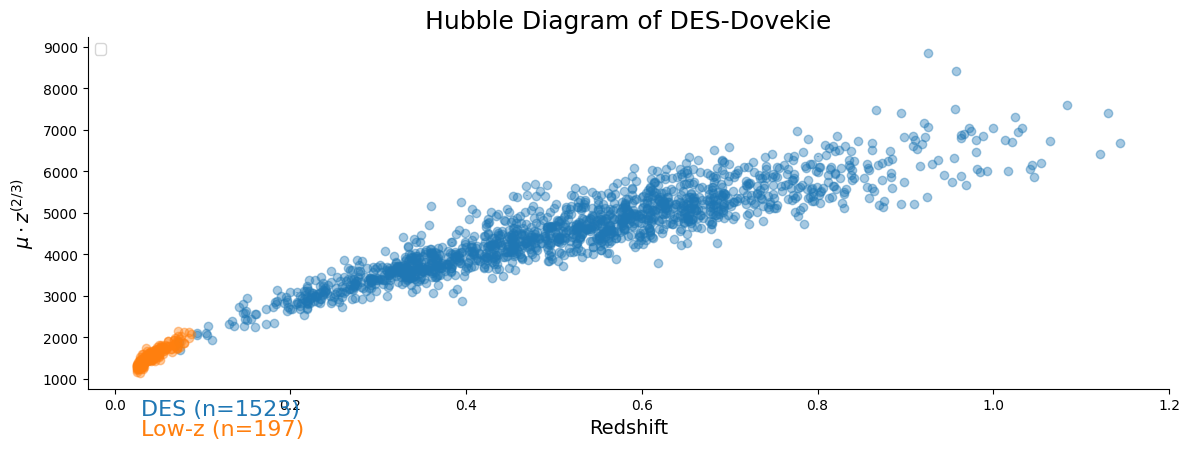

In [175]:
fig, ax = plt.subplots(figsize=(12, 4.6))

# data
plt.errorbar(
    high_z['zHD'], 10**(high_z['MU']/5-5) / high_z['zHD']**(2/3),
    yerr=high_z['MUERR'],
    fmt='o', alpha=0.4, color='tab:blue'
)

plt.errorbar(
    low_z['zHD'], 10**(low_z['MU']/5-5) / low_z['zHD']**(2/3),
    yerr=low_z['MUERR'],
    fmt='o', alpha=0.4, color='tab:orange'
)

# lCDM posterior band
# ax.plot(z_grid, mu_med*z_grid**(2/3), color='black', label='Best-fit $\Lambda$CDM', zorder=10)
# ax.fill_between(z_grid, mu_16*z_grid**(2/3), mu_84*z_grid**(2/3), color='gray', alpha=0.3, zorder=9)

# # comparison models
# ax.plot(z_grid, fwcdm_sampler.mu_model_corrected(fwcdm_sampler.burned.sample(n=1).to_numpy().flatten(), z_grid)*z_grid**(2/3), color='gray', linestyle='--', zorder=9, label='Flat $\omega$CDM')

ax.set_xlabel('Redshift', size=14)
ax.set_ylabel('$\mu \cdot z^{(2/3)}$', size=14)
ax.set_title('Hubble Diagram of DES-Dovekie', size=18)
ax.text(0.03, 35, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
ax.text(0.03, 34.75, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
ax.legend(loc='upper left')

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

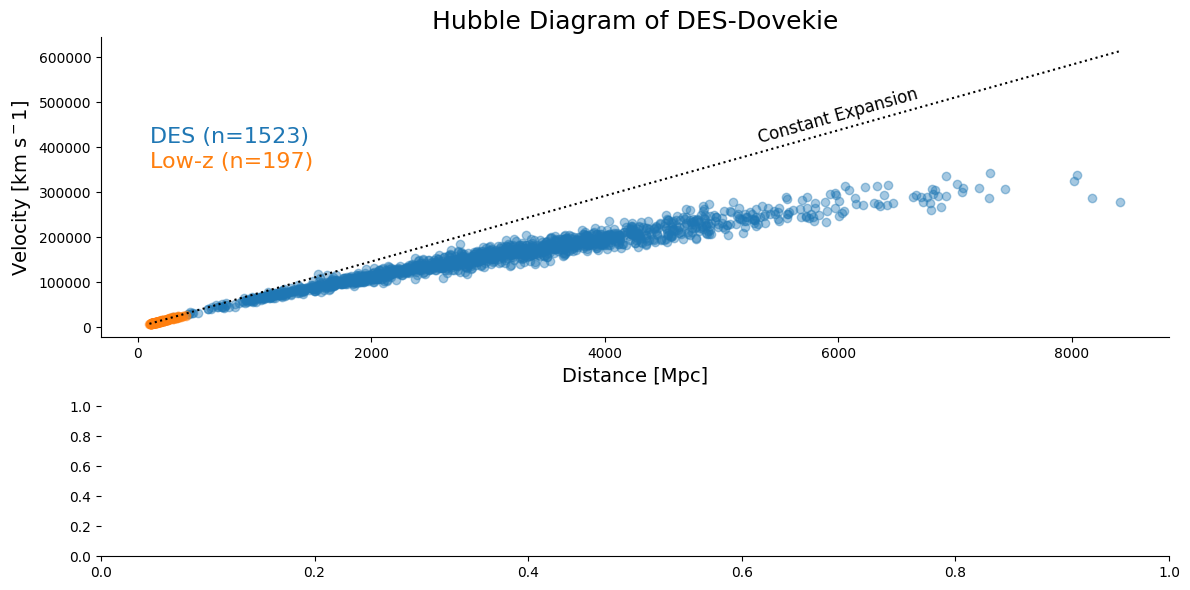

In [164]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={'height_ratios': [2, 1]})

# data
ax1.errorbar(
    10**((high_z['MU']-25)/5), high_z['zHD'] * 3e5,
    yerr=high_z['MUERR'],
    fmt='o', alpha=0.4, color='tab:blue'
)

ax1.errorbar(
    10**((low_z['MU']-25)/5), low_z['zHD'] * 3e5,
    yerr=low_z['MUERR'],
    fmt='o', alpha=0.4, color='tab:orange'
)

d_grid = np.linspace(np.min(10**((df['MU']-25)/5)), np.max(10**((df['MU']-25)/5)), 200)
ax1.plot(d_grid, d_grid * 73, linestyle='dotted', color='black', zorder=9)

rotn = np.degrees(np.arctan2(73*(d_grid[1]-d_grid[0]), d_grid[1]-d_grid[0]))
ax1.annotate('Constant Expansion', xy=(6000, 4.7e5), ha='center', va='center', rotation=rotn, transform_rotates_text=True, fontsize=12)

ax1.set_ylabel('Velocity [km s$^-1$]', size=14)
ax1.set_xlabel('Distance [Mpc]', size=14)
ax1.set_title('Hubble Diagram of DES-Dovekie', size=18)
ax1.text(100, 4e5, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
ax1.text(100, 3.9e5, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
# ax1.legend(loc='upper left')

ax1.spines[['top', 'right']].set_visible(False)
ax2.spines[['top', 'left', 'right']].set_visible(False)

plt.tight_layout()
plt.show()